# Step 1

This is our clean and refactored version of our first implementation phase. We could add a small descption here but not right now xD. If in need, check out the prototypes :)

In [1]:
# Import Gurobi
import gurobipy as gp
from gurobipy import GRB

# Test Plotting
from Plotting.chris_v1 import plot_simple_timetable
from Plotting.chris_v1_revised import plot_timetable

In [2]:
# Initialize the Model
model = gp.Model("Basic_MILP")

Restricted license - for non-production use only - expires 2027-11-29


In [3]:
# Define the track system using dictionaries to have homogeneous lists and allow for precise track building

# Copy preset for faster building
# {"type": "station", "capacity": 0}
# {"type": "segment", "length": 0, "capacity": 0}

track_blueprint = [
    {"type": "station", "capacity": 3},
    {"type": "segment", "length": 5, "capacity": 1},
    {"type": "station", "capacity": 2},
    {"type": "segment", "length": 2, "capacity": 2},
    {"type": "station", "capacity": 3}
]

In [4]:
# Parsing the track blueprint and generating necessary data (1D lists for Gurobi)
# These store the allowed number of trains on a given block and which blocks are train stations

block_capacities = []
is_station = []

for item in track_blueprint:
    if item["type"] == "station":
        block_capacities.append(item["capacity"])
        is_station.append(True)
    elif item["type"] == "segment":
        # Int conversion not necessary, but gets rid of IDE highlighting
        for _ in range(int(item["length"])):
            block_capacities.append(item["capacity"])
            is_station.append(False)
    else:
        print("typo? No other types yet...")

In [5]:
# Similar to our track_blueprint, we use dictionaries for the schedules for a given train
# Especially here, this allows for basically arbitrary additional data that can be used for
# different optimizing goals and constraints. This also nicely handles, that a train doesn't
# have to stop at every station.

# Structure: [train_i_stop_information_dictionary{station_index_i: information{some_key: some_value}}]
# Note: Due to the implementation ('looking-back') departure_times_i has to be >= 1
train_schedules = [
    # Train 0
    {
        # Station x
        0: {"departure": 3},
        1: {"arrival": 10, "departure": 13},
        2: {"arrival": 12, "departure": 17},
    },
    # Train 1
    {
        # Station x
        0: {"departure": 5},

        # Think what dwell should / might mean in combination with a departure time ('overpower', something else?)
        # Is not implemented at this point but will be used later...
        2: {"arrival": 10, "departure": 18, "dwell": 2},
    },
]

In [6]:
# Number of time steps over which we optimize
time_horizon = 25

# Deriving some additional variables for bounding variables
num_trains = len(train_schedules)
num_blocks = len(block_capacities)
num_stations = sum(is_station)

# List of all block indices that are stations
station_block_indices = [block for block, station_idx in enumerate(is_station) if station_idx]

In [7]:
# Define Decision Variables

# To describe our train movement we need a way to know which train is where at what
# time (-> 3D time-position grid of boolean values)

x = model.addVars(num_trains, num_blocks, time_horizon, vtype=GRB.BINARY, name="x")

### Constraints

#### General Constraints

As general constraints, we have the
- uniqueness constraint (no train can be on multiple tracks at once)
- spawning constraint (a train does not 'exist' until it leaves from the first station in its schedule). For future iterations we should also think about if we want to keep the spawning behavior or replace (or even remove?) it...
- capacity constraints (there can't exist more trains on a block (or station) than its capacity)

#### Movement Constraints

For now, we have the
- 'at most one block per timestep' constraint (will likely be changed in the next phase (step 2) to allow for different train speeds)
- 'departure-time constraint' (trains don't have to stop at stations if they are not on their schedule and also, they can't leave a station until their departure time)

In [8]:
# Uniqueness constraint for trains to only exist once on a block (on only a single track at a given time)
# Additionally, we tackle the spawning (departure times), as before a train does not exist on any block
for i in range(num_trains):

    # Since dictionaries are unordered, use this to get spawn time (first departure time)
    spawn_station_id = sorted(train_schedules[i].keys())[0]
    spawn_time = train_schedules[i][spawn_station_id]["departure"]

    for k in range(time_horizon):

        # Sum over all blocks j to ensure that a train only exists once at a given time k
        active_tracks = gp.quicksum(x[i, j, k] for j in range(num_blocks))

        # If the train hasn't spawned (or left) yet, it can't exist on the track and we enforce this
        if k < spawn_time:
            model.addConstr(active_tracks == 0, name=f"NotSpawned_Train{i}_Time{k}")
        else:
            # If it already exists, we enforce that the train only exists on one track at any time k
            model.addConstr(active_tracks == 1, name=f"UniquePosition_Train{i}_Time{k}")

In [9]:
# Capacity constraints (the sum over all tracks j and all trains i <= capacities_i)
for k in range(time_horizon):

    # Here we want to sum over all i AND j and add the constraint that this should be smaller than
    # Is this formulation correct and can this be made more compact (yes: x.sum('*', j, k))?
    for j in range(num_blocks):
        occupied_tracks = gp.quicksum(x[i, j, k] for i in range(num_trains))

        # Add constraint to enforce capacity maximum across block j
        model.addConstr(occupied_tracks <= block_capacities[j], name=f"Capacity_Block{j}_Time{k}")

In [10]:
# Movement Constraints

# A train can (after spawning) either wait or move
for i in range(num_trains):

    # (Copied, consider helper function or dedicated list as a global variable)
    # Since dictionaries are unordered, use this to get spawn time (first departure time)
    spawn_station_id = sorted(train_schedules[i].keys())[0]
    spawn_time = train_schedules[i][spawn_station_id]["departure"]

    # At every time point, we need to differentiate between different scenarios
    for k in range(time_horizon):

        # If the train hasn't left yet, it's not yet on the grid and the spawn constraint takes care of this
        if k < spawn_time:
            pass
        # Here the train spawns, and we fix a position (the block that corresponds to the first station on
        # the trains schedule)
        elif k == spawn_time:

            # Here we can again use the spawn_station_id
            block_index = station_block_indices[spawn_station_id]

            model.addConstr(x[i, block_index, k] == 1, name=f"Spawn_Train{i}_Time{k}_on_Block0")
        else:

            # Handle out back-looking approach
            for j in range(num_blocks):

                # If the train is on block one, it must have already been there (j is always ≠ -1)
                if j == 0:
                    model.addConstr(x[i, 0, k] <= x[i, 0, k - 1], name=f"Move_Train{i}_Time{k}_Block0")
                else:
                    # General back-look constraint (train must have been here or in the previous block)
                    model.addConstr(x[i, j, k] <= x[i, j, k - 1] + x[i, j - 1, k - 1], name=f"Move_Train{i}_Time{k}_Block{j}")

In [11]:
# Now, we want to add the constraints for intermediate stations (arrival and departure times and no spawning)
# In this version we only tackle departure times and not dwell times yet

# For every train
for i in range(num_trains):

    # Get the spawn station ID so we can skip it (this is already handled by the spawning constraint)
    spawn_station_id = sorted(train_schedules[i].keys())[0]

    # Iterate directly through this train's schedule
    for station_id, schedule in train_schedules[i].items():

        # Skip the spawn station (already handled)
        if station_id == spawn_station_id:
            continue

        # Check if this station has a strict leave time (might always be the case, but we'll see)
        if "departure" in schedule:
            leave_time = schedule["departure"]
            station_block = station_block_indices[station_id]
            next_block = station_block + 1

            # Ensure we don't look past the end of the tracks (should only be an issue with the last station)
            if next_block < num_blocks:

                # Build the wall: The train cannot enter the next block before the leave time
                for k in range(leave_time):
                    model.addConstr(
                        x[i, next_block, k] == 0,
                        name=f"DepartureWall_Train{i}_Block{next_block}_Time{k}"
                    )
            else:
                # Here we might have some code later when having more complex schedules and a train e.g.,
                # 'turns around' and continues its journey back to the initial station. However, this
                # might then also be handled differently again...
                pass

### Model Objective

For the new model objective, we have to figure out how we can formulate something in respect to the actual arrival time of a train (similarly we can implement dwell times). Mathematically, arrival happens when

$$x_{i, \text{station}}, k = 1 \quad \text{AND} \quad x_{i, \text{station}}, k-1 = 0 \, .$$

So we later probably want to loop over all trains and all stations (except probably the spawning station) and compute / consider lateness that way. For now however, we will likely only focus on the destination station.

**Thought:** Should we also reward 'early arrival'? This might be good as then there is a larger buffer for trains in a realistic and dynamic setting, however here it might actually be counterproductive as it could encourage actual delays if enough trains benefit through early arrivals... Using additional (smaller) goals like minimizing travel times for passengers should yield the same results, prohibiting lazy solves and represent an actual optimization of the network.

To formulate our more complex constraints, we need an indicator for the event of arriving at a station. Here we use the transition

$$T_k = x_{i, s, k} - x_{i, s, k-1} \, .$$

Evaluating the four different possible options
1. Train is not here yet ($0 - 0 = 0$)
2. Train just arrived ($1 - 0 = 1$) $\leftarrow$ This is what we want
3. Train is waiting here ($1 - 1 = 0$)
4. Train just left ($0 - 1 = -1$)

shows, that we want to check for / enforce $T_k = 1$. Also, note that an addition would not work here due to commutability and therefore ambiguity. With this we can then formulate a penalty for lateness that we want to minimize:

$$\text{Penalty} = \sum_{k > \text{arrival}} (k - \text{arrival}) \cdot (x_{i, s, k} - x_{i, s, k-1})$$

Note, that this should only trigger exactly once per train (when only taking lateness at the destination station into account) and then add a penalty of $(k - \text{arrival})$.

One issue that we might run into (we'll see though), is that the optimizer might simply not let the train arrive at the last station if it is late (and other trains can pass) to minimize the penalty like this — and not actually the lateness xD. What might be a good workaround for this? Or do we even need one, and if so, in what scenarios?

$\implies$ This was indeed an issue. For now, we fixed it with the additional train that a train always has to reach its destination in the given time horizon. This might later be changes or made redundant with modifications to the objective.

In [12]:
# New Objective (considering only lateness at the destination station)

# Map the final station ID to the physical block index
destination_keys = [sorted(train_schedules[i].keys())[-1] for i in range(num_trains)]
destination_blocks = [station_block_indices[key] for key in destination_keys]

# Adding an additional constraint to ensure that a train drives to its destination station
# and not allowing the optimizer to cheese its way out of a lateness penalty:
# Force every train to reach its destination by the end of the horizon
for i in range(num_trains):
    dest_block = destination_blocks[i]
    last_t = time_horizon - 1

    model.addConstr(x[i, dest_block, last_t] == 1, name=f"MustFinish_Train{i}")

# Get the target arrival times
target_arrivals = [train_schedules[i][destination_keys[i]]["arrival"] for i in range(num_trains)]

# List to store our terms contributing to the lateness penalty
objective_terms = []

# Loop over all trains
for i in range(num_trains):
    destination_block = destination_blocks[i]
    target_time = target_arrivals[i]

    # We only loop over k starting from the minute after the train is supposed to arrive
    # If they arrive at or before target_time, it is not penalized (adds 0)
    for k in range(target_time + 1, time_horizon):
        # Calculate the positive delay multiplier
        delay_penalty = k - target_time

        # Compute the transition value to check for arrival
        transition = x[i, destination_block, k] - x[i, destination_block, k - 1]

        # Multiply by the arrival transition at the destination block and add to our objective list
        objective_terms.append(delay_penalty * transition)

model.setObjective(gp.quicksum(objective_terms), GRB.MINIMIZE)

In [13]:
# Run the optimization
model.optimize()

# Code by Gemini

# Print the results if an optimal solution is found
if model.Status == GRB.OPTIMAL:
    print("\n" + "="*30)
    print("🚂 OPTIMAL SCHEDULE FOUND 🚂")
    print("="*30)

    for i in range(num_trains):
        print(f"\n--- Train {i} ---")
        for k in range(time_horizon):
            for j in range(num_blocks):
                # .X extracts the solved value from the Gurobi variable.
                # We check > 0.5 to account for minor floating-point tolerances in the solver.
                if x[i, j, k].X > 0.5:
                    if is_station[j]:
                        print(f"Time {k:2d} -> Station {j}")
                    else:
                        print(f"Time {k:2d} -> Block {j}")
else:
    print("\n❌ No optimal solution found. The model might be Infeasible.")

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7640HS w/ Radeon 760M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 717 rows, 500 columns and 2177 nonzeros (Min)
Model fingerprint: 0x79c3f470
Model has 28 linear objective coefficients
Variable types: 0 continuous, 500 integer (500 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 3e+00]

Presolve removed 422 rows and 288 columns
Presolve time: 0.01s
Presolved: 295 rows, 212 columns, 922 nonzeros
Variable types: 0 continuous, 212 integer (212 binary)
Found heuristic solution: objective 21.0000000
Found heuristic solution: objective 16.0000000
Found heuristic solution: objective 15.0000000

Root relaxation: objective 7.000000e+00, 35 iterations, 0.00 seconds (0.00 work

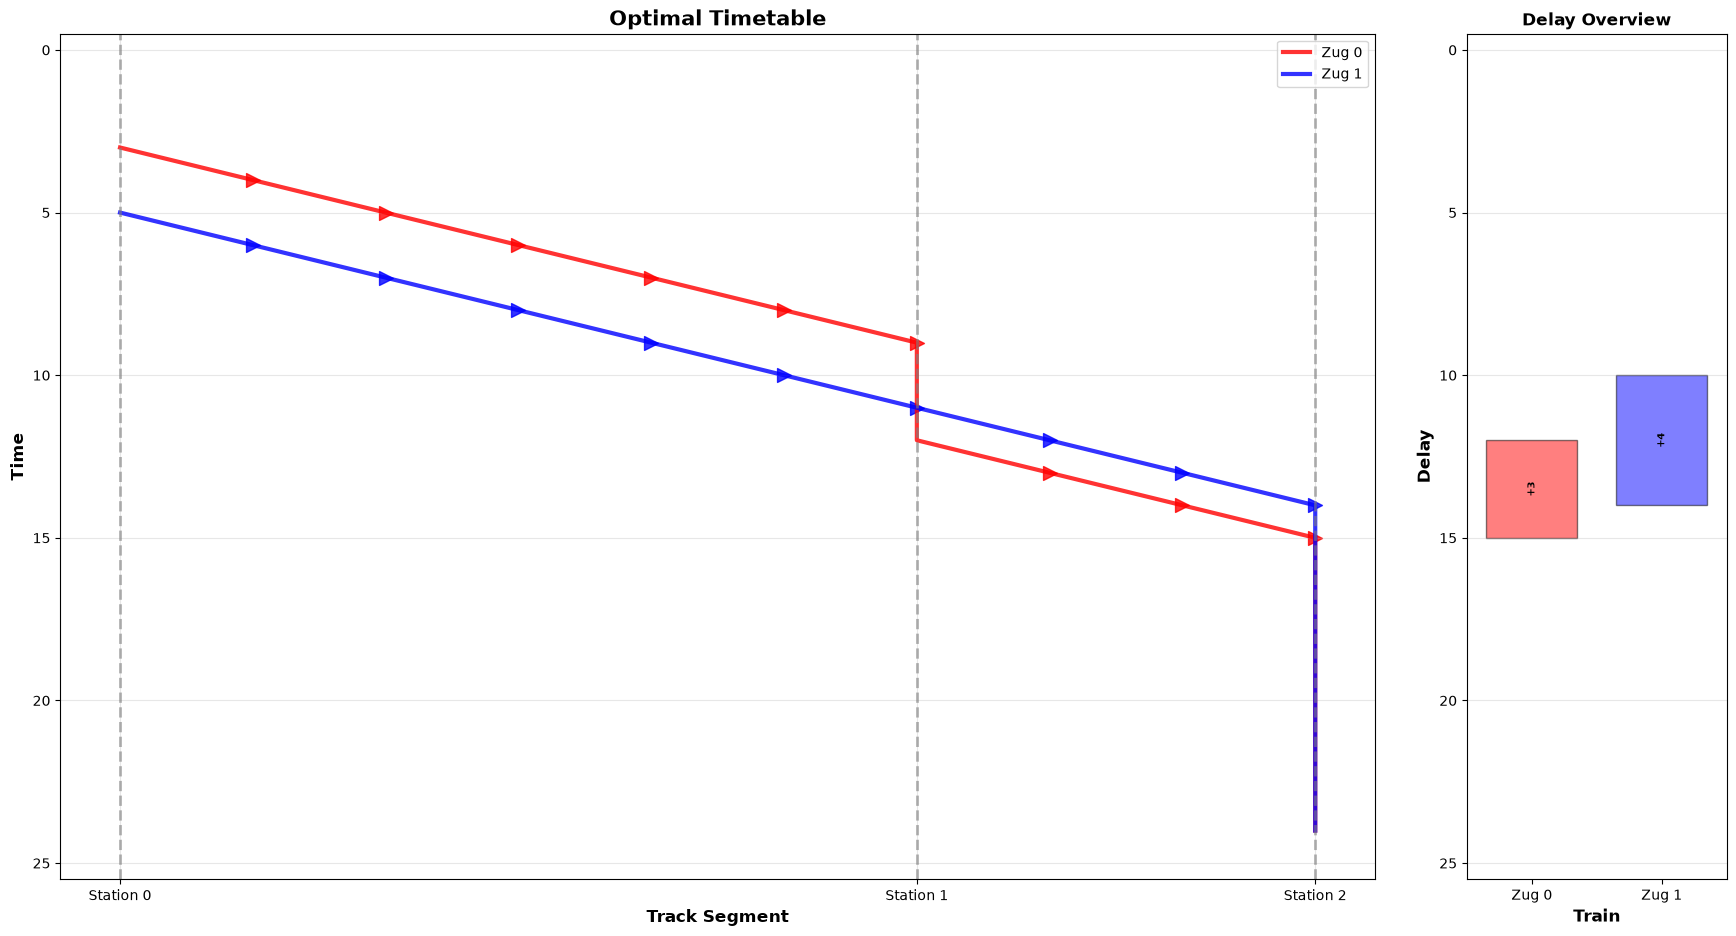

(<Figure size 1800x1000 with 2 Axes>,
 (<Axes: title={'center': 'Optimal Timetable'}, xlabel='Track Segment', ylabel='Time'>,
  <Axes: title={'center': 'Delay Overview'}, xlabel='Train', ylabel='Delay'>))

In [14]:
plot_simple_timetable(num_trains, num_blocks, time_horizon, x, is_station, track_blueprint, train_schedules)

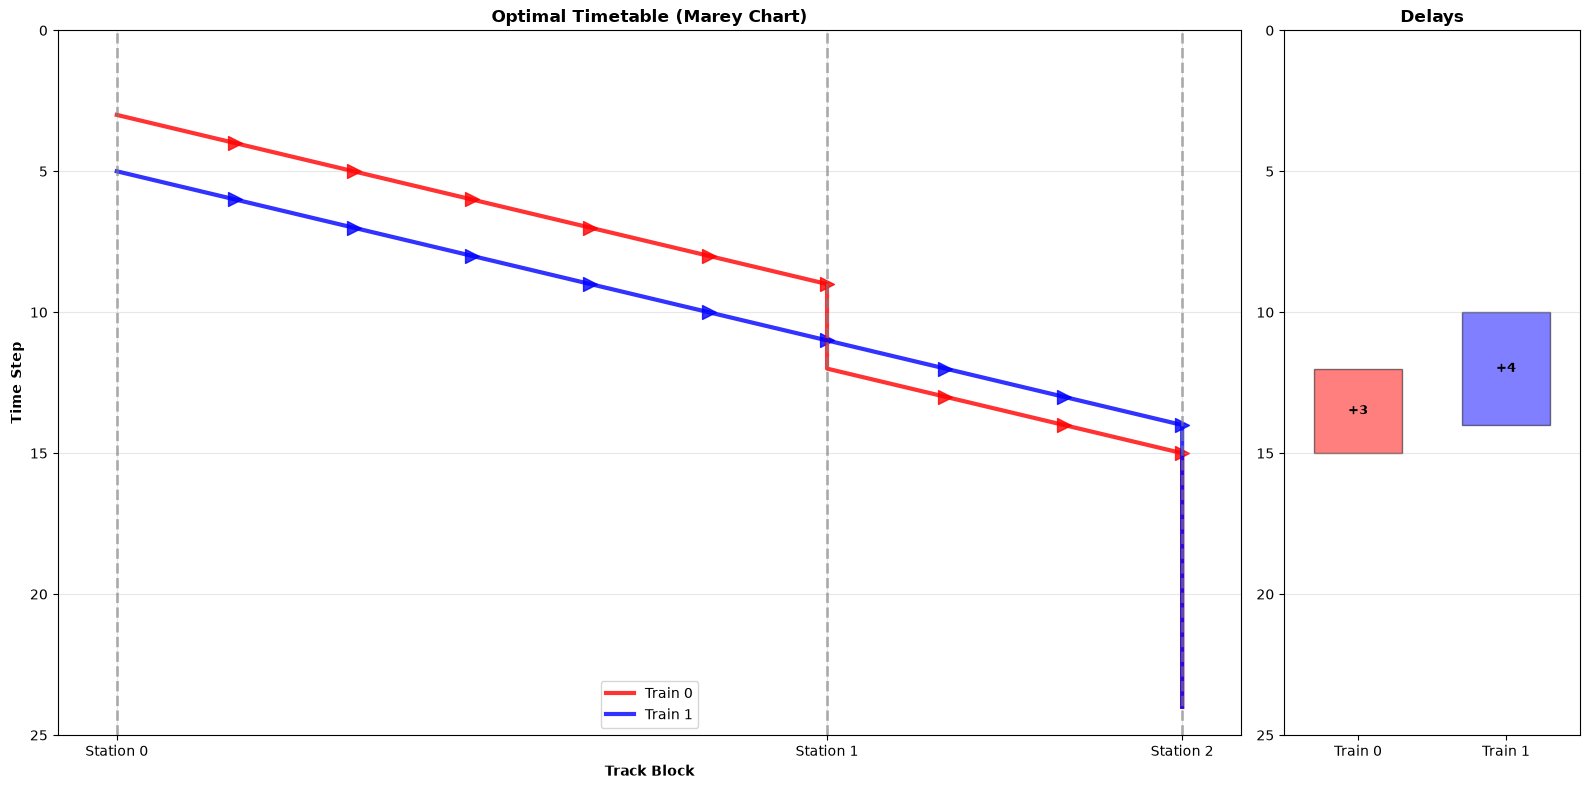

In [16]:
plot_timetable(x, station_block_indices, train_schedules)